# Emotion Recognition Using Audio Features

In [14]:
import os, csv
import torch
import soundfile as sf
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import snapshot_download

import torch
from IPython.display import Audio
import pandas as pd


import torch
import torchaudio

import torch
import torchaudio.functional as AF

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
)

In [2]:
EMO2IDX = {"angry": 0, "happy": 1, "neutral": 2, "sad": 3}
IDX2EMO = {"0": "angry", "1": "happy", "2": "neutral", "3": "sad"}

ROOT = snapshot_download("OlhaHavryliuk/UA-SER", repo_type="dataset")


class UASER(Dataset):
    def __init__(self, split):
        self.dir = os.path.join(ROOT, "clips")
        self.rows = [r for r in csv.DictReader(open(os.path.join(ROOT, "dataset.csv")))
                     if r["split"] == split]

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        wav, _ = sf.read(os.path.join(self.dir, r["filename"]), dtype="float32")
        return torch.from_numpy(wav), EMO2IDX[r["emotion"]]


def collate(batch):
    wavs, labels = zip(*batch)
    T = max(w.shape[0] for w in wavs)
    audio = torch.zeros(len(wavs), T)
    for i, w in enumerate(wavs):
        audio[i, : w.shape[0]] = w
    return audio, torch.tensor(labels)


train_loader = DataLoader(UASER("train"), batch_size=16, shuffle=True, collate_fn=collate)
test_loader  = DataLoader(UASER("test"),  batch_size=16, collate_fn=collate)


if __name__ == "__main__":
    print("train:", len(train_loader.dataset), "| test:", len(test_loader.dataset))
    audio, labels = next(iter(train_loader))
    print(audio.shape, labels.tolist())

Fetching 955 files:   0%|          | 0/955 [00:00<?, ?it/s]

train: 771 | test: 181
torch.Size([16, 68021]) [2, 1, 3, 0, 1, 2, 3, 1, 1, 3, 2, 2, 0, 2, 0, 0]


# Spectral Features

In [3]:
audio1, label1 = audio[0], labels[0]
sample_rate = 16000

In [26]:
def get_mfcc(audio, sample_rate=sample_rate):
    if audio.ndim == 1:
        waveform = audio.unsqueeze(0)
        
        mfcc_transform = torchaudio.transforms.MFCC(
            sample_rate=sample_rate,
            n_mfcc=13,
            melkwargs={
                "n_fft": 400,
                "hop_length": 160,
                "n_mels": 40,
            }
        )
        
        mfcc = mfcc_transform(waveform)
        return mfcc


def get_f0(audio, sample_rate=sample_rate):
    if audio.ndim == 1:
        waveform = audio.unsqueeze(0)
    
    f0 = AF.detect_pitch_frequency(
        waveform,
        sample_rate=sample_rate,
        frame_time=0.01, 
        freq_low=50,
        freq_high=500,
    )
    
    time = torch.arange(f0.shape[-1]) * 0.01 
    return f0, time


def get_rms(audio, sample_rate=sample_rate):
    if audio.ndim == 1:
        waveform = audio.unsqueeze(0)

    frames = waveform.unfold(
        dimension=-1,
        size=400,
        step=160
    )

    rms = torch.sqrt(torch.mean(frames ** 2, dim=-1) + 1e-8)
    time = torch.arange(rms.shape[-1]) * 160 / sample_rate
    return rms, time


def get_0crossing(audio, sample_rate=sample_rate):
    if audio.ndim == 1:
        waveform = audio.unsqueeze(0)

    frames = waveform.unfold(
        dimension=-1,
        size=400,
        step=160
    )

    zero_crossings = (frames[..., 1:] * frames[..., :-1]) < 0
    zcr = zero_crossings.float().mean(dim=-1)
    time = torch.arange(zcr.shape[-1]) * 160 / sample_rate
    return zcr, time

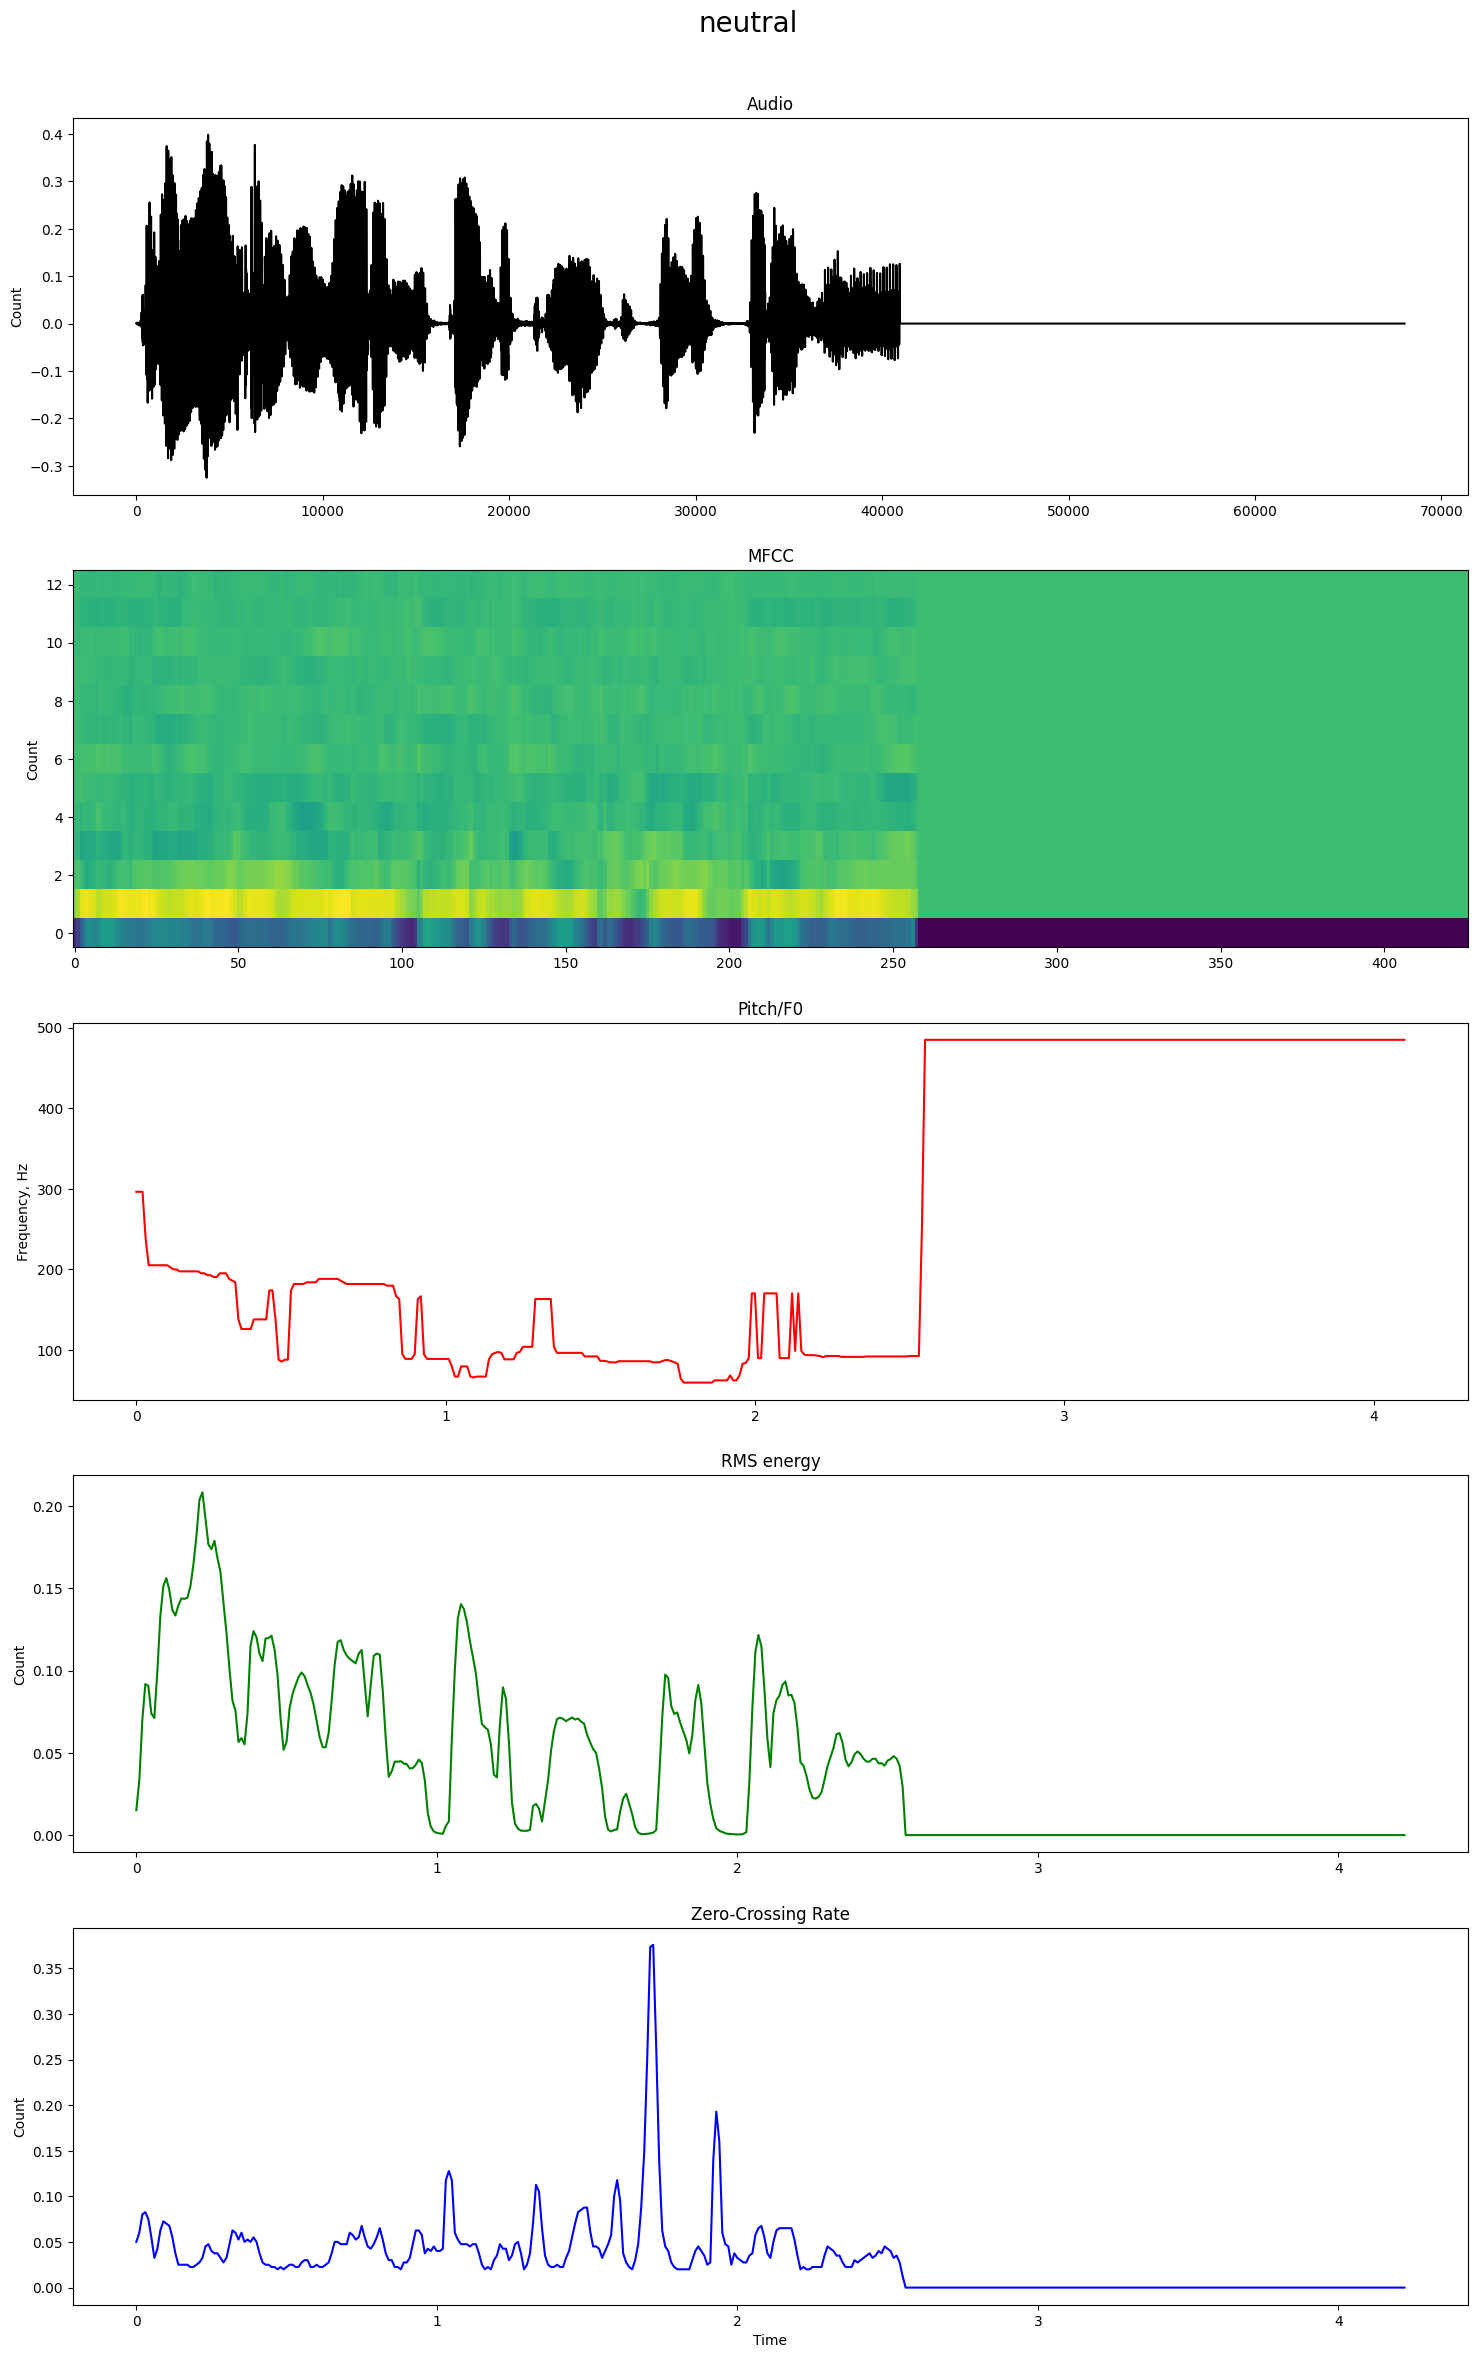

In [27]:
def plot_acoustic_features(audio=audio1, label=label1):
    emo = IDX2EMO[str(int(label1))]
    fig, axes = plt.subplots(5, 1, figsize=(18, 27)) 
    
    fig.suptitle(emo, fontsize=20, y=0.96)
    fig.subplots_adjust(top=0.92)    
    
    axes[0].plot(audio1, color='Black')
    axes[0].set(ylabel='Count', title="Audio")

    mfcc = get_mfcc(audio1)
    axes[1].imshow(mfcc[0].detach().numpy(), aspect="auto", origin="lower")
    axes[1].set(ylabel='Count', title="MFCC")

    f0, time = get_f0(audio1)
    axes[2].plot(time.numpy(), f0[0].numpy(), color='red')
    axes[2].set(ylabel='Frequency, Hz', title="Pitch/F0")

    rms, time = get_rms(audio1)
    axes[3].plot(time.numpy(), rms[0].numpy(), color='green')
    axes[3].set(ylabel='Count', title="RMS energy")

    zcr, time = get_0crossing(audio1)
    axes[4].plot(time.numpy(), zcr[0].numpy(), color='blue')
    axes[4].set(xlabel='Time', ylabel='Count', title="Zero-Crossing Rate")

plot_acoustic_features()

In [6]:
play_audio = audio1.detach().cpu().numpy()
Audio(play_audio, rate=sample_rate)

## Models

In [7]:
def metrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    uar = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    return [int(accuracy), int(uar), int(macro_f1)]

In [8]:
def to_np(loader, target_len):
    all_x, all_y = [], []

    for x, y in loader:
        x, y = x.detach().cpu(), y.detach().cpu()

        for i in range(x.shape[0]):
            sample = x[i].reshape(-1).numpy()
            sample = np.asarray(sample, dtype=np.float32)

            if len(sample) > target_len:
                sample = sample[:target_len]
            elif len(sample) < target_len:
                sample = np.pad(
                    sample,
                    (0, target_len - len(sample)),
                    mode="constant"
                )

            all_x.append(sample)

        if y.ndim > 1:
            y = torch.argmax(y, dim=1)

        all_y.append(y.numpy())

    all_x = np.stack(all_x)
    all_y = np.concatenate(all_y, axis=0)
    return all_x, all_y


target_len = sample_rate * 3  # 3 seconds

x_train, y_train = to_np(train_loader, target_len)
x_test, y_test = to_np(test_loader, target_len)

In [12]:
names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
]

classifiers = [
    KNeighborsClassifier(n_neighbors=4),
    SVC(kernel="linear", class_weight="balanced", C=0.025, random_state=42),
    SVC(kernel="rbf", gamma=2, C=1, class_weight="balanced", random_state=42),    
    DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    RandomForestClassifier(
        max_depth=5, max_features="sqrt", class_weight="balanced", n_estimators=100, random_state=42),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
]

result = {}
for name, clf in zip(names, classifiers):
    result[name] = {}

    clf.fit(x_train, y_train)
    preds = clf.predict(x_test)
    score = metrics(preds, y_test)
        
    result[name] = {
            "accuracy": score[0],
            "uar": score[1],
            "macro_f1": score[2],
        }
result

{'Nearest Neighbors': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'Linear SVM': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'RBF SVM': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'Decision Tree': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'Random Forest': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'Neural Net': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'AdaBoost': {'accuracy': 1, 'uar': 1, 'macro_f1': 1},
 'Naive Bayes': {'accuracy': 1, 'uar': 1, 'macro_f1': 1}}

In [18]:
df_result = pd.DataFrame(result).T
df_result.to_csv("base_metrics.csv", index=False)
df_result

,accuracy,uar,macro_f1
Nearest Neighbors,1,1,1
Linear SVM,1,1,1
RBF SVM,1,1,1
Decision Tree,1,1,1
Random Forest,1,1,1
Neural Net,1,1,1
AdaBoost,1,1,1
Naive Bayes,1,1,1
